Importando Pandas, numpy para um cálculo, decisiontree, várias avaliações e técnicas de cross validation

In [9]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier # Importar Decision Tree Classifier
from sklearn.model_selection import train_test_split, cross_val_score, KFold, RepeatedKFold, LeaveOneOut, LeavePOut 
from sklearn import metrics #Import scikit-learn metrics module for accuracy calculation
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score, silhouette_score
import matplotlib.pyplot as plt
from sklearn.metrics import adjusted_rand_score
import hdbscan
from sklearn.metrics import adjusted_rand_score

Importando coisas relacionadas ao hiperparâmetros

In [10]:
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, HalvingGridSearchCV, HalvingRandomSearchCV
from scipy.stats import randint 

Selecionar as features do csv original do iris e carregar o dataset

In [11]:
col_names = ['SepalLength', 'SepalWidth', 'PetalLength', 'PetalWidth', 'Name']
iris = pd.read_csv("iris.csv.xls")

feature_cols = ['SepalLength', 'SepalWidth', 'PetalLength', 'PetalWidth']
X = iris[feature_cols] # Features
y = iris.Name # Target variable

Treinando com treino e teste (método tradicional que sempre vimos/usamos)

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1) # 80% training and 20% test

clf = DecisionTreeClassifier()
clf = clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)
print("Accuracy com gini:",metrics.accuracy_score(y_test, y_pred))

Accuracy com gini: 0.9666666666666667


Verificando o formato da estrutura de treino e teste originais acima selecionados

In [13]:
#Verificando
print ("X shape, y shape", X.shape, y.shape)
print ("X train, y train", X_train.shape, y_train.shape)
print ("X test, y test", X_test.shape, y_test.shape)
print(clf.score(X_test,y_test)) #mesma coisa que o metrics.accuracy_score

X shape, y shape (150, 4) (150,)
X train, y train (120, 4) (120,)
X test, y test (30, 4) (30,)
0.9666666666666667


Teste do cross-validation (ou validação cruzada) e quero saber o desempenho dele (qual a nota em acuracia)

In [14]:
scores = cross_val_score(clf, X, y, cv=5, scoring='f1_macro')
print("Valor de CV 5: ", scores, "\nMedia e Desvio Padrao: ", scores.mean(), scores.std())

Valor de CV 5:  [0.96658312 0.96658312 0.89974937 0.96658312 1.        ] 
Media e Desvio Padrao:  0.9598997493734336 0.032741717530936375


Testando k-fold e outras técnicas

In [15]:
k = 5
kf = KFold(n_splits=4, shuffle=True, random_state=42)
scores = cross_val_score(clf, X, y, cv=kf, scoring='f1_macro')
print("Valor de KFOLD 4: ", scores, "\nMedia e Desvio: ", scores.mean(), scores.std())

Valor de KFOLD 4:  [1.         0.91652174 0.88811189 0.95396825] 
Media e Desvio:  0.9396504703026443 0.04194707475991883


Testando o Random K-Fold

In [16]:
rkf = RepeatedKFold(n_splits=4, n_repeats=2, random_state=42)
scores = cross_val_score(clf, X, y, cv=rkf, scoring='f1_macro')
print("Valor de RepeatedKFOLD 4: ", scores, "\nMedia e Desvio: ", scores.mean(), scores.std())

Valor de RepeatedKFOLD 4:  [1.         0.97178131 0.88811189 0.95396825 0.96804648 1.
 0.92795031 0.92012289] 
Media e Desvio:  0.9537476404336263 0.03693314604010557


Testando o Leave one out

In [17]:
loo = LeaveOneOut()
scores = cross_val_score(clf, X, y, cv=loo)
print("Valor de loo: ", scores, "\nMedia e Desvio: ", scores.mean(), scores.std())

Valor de loo:  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1.
 1. 1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 1. 1. 0. 1. 1. 1. 1. 0. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1.] 
Media e Desvio:  0.9466666666666667 0.22469732728470287


In [18]:
lpo = LeavePOut(p=2)
scores = cross_val_score(clf, X, y, cv=lpo)
print("Valor de lpo: ", scores, "\nMedia e Desvio: ", scores.mean(), scores.std())

Valor de lpo:  [1. 1. 1. ... 1. 1. 1.] 
Media e Desvio:  0.9485906040268456 0.1562179691055009


Agora com hiperparâmetros para o RandomSearch: definindo os hiperparâmetros que analisarei aleatoriamente

In [19]:
param_distRandom = {"max_depth": [3, None],
    "max_features": randint(1, 9),
    "min_samples_leaf": randint(1, 9),
    "criterion": ["gini", "entropy", "log_loss"]}

clf2 = DecisionTreeClassifier()
clf_cv2 = RandomizedSearchCV(clf2, param_distRandom, cv=5)
clf_cv2 = clf_cv2.fit(X_train, y_train)

print("Tuned Decision Tree Parameters: {}".format(clf_cv2.best_params_))
print("Best score is {}".format(clf_cv2.best_score_))

Tuned Decision Tree Parameters: {'criterion': 'log_loss', 'max_depth': 3, 'max_features': 2, 'min_samples_leaf': 2}
Best score is 0.9583333333333334


Agora com hiperparâmetros para o GridSearch: definindo os hiperparâmetros que analisarei exaustivamente

In [20]:
param_dist = {"max_depth": [3, None],
    "max_features": [1, 2, 3, 4, 5, 6, 7, 8, 9],
    "min_samples_leaf": [1, 2, 3, 4, 5, 6, 7, 8, 9],
    "criterion": ["gini", "entropy", "log_loss"]}

clf3 = DecisionTreeClassifier()
clf_cv3 = GridSearchCV(clf3, param_dist, cv=5)
clf_cv3 = clf_cv3.fit(X_train, y_train)
print("Tuned Decision Tree Parameters: {}".format(clf_cv3.best_params_))
print("Best score is {}".format(clf_cv3.best_score_))

Tuned Decision Tree Parameters: {'criterion': 'log_loss', 'max_depth': 3, 'max_features': 3, 'min_samples_leaf': 8}
Best score is 0.9666666666666668


DBSCAN

In [21]:
# Padronização dos dados
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Modelo DBSCAN
dbscan = DBSCAN(
    eps=0.8,
    min_samples=5
)

clusters = dbscan.fit_predict(X_scaled)

print("Clusters encontrados:", set(clusters))
print("Quantidade por cluster:")
print(pd.Series(clusters).value_counts().sort_index())

# Avaliação
ari = adjusted_rand_score(y, clusters)
print("Adjusted Rand Index:", ari)

if len(set(clusters)) > 1:
    sil = silhouette_score(X_scaled, clusters)
    print("Silhouette Score:", sil)

Clusters encontrados: {np.int64(0), np.int64(1), np.int64(-1)}
Quantidade por cluster:
-1     4
 0    49
 1    97
Name: count, dtype: int64
Adjusted Rand Index: 0.5517553852833211
Silhouette Score: 0.5205966153011559


Visualização dos Clusters

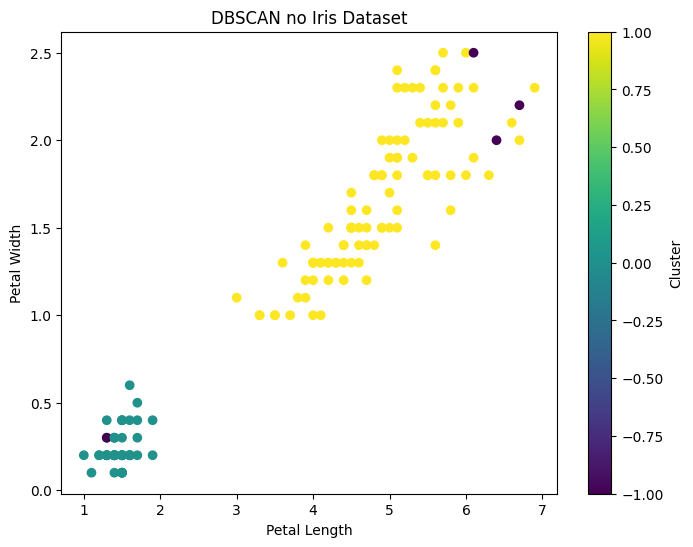

In [22]:
plt.figure(figsize=(8,6))

plt.scatter(
    X['PetalLength'],
    X['PetalWidth'],
    c=clusters,
    cmap='viridis'
)

plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("DBSCAN no Iris Dataset")
plt.colorbar(label="Cluster")
plt.show()

Testando vários parâmetros

In [23]:
melhor_ari = -1
melhor_eps = None

for eps in np.arange(0.2, 2.1, 0.1):

    modelo = DBSCAN(
        eps=eps,
        min_samples=5
    )

    pred = modelo.fit_predict(X_scaled)

    if len(set(pred)) > 1:
        ari = adjusted_rand_score(y, pred)

        if ari > melhor_ari:
            melhor_ari = ari
            melhor_eps = eps

print("Melhor eps:", melhor_eps)
print("Melhor ARI:", melhor_ari)

Melhor eps: 1.5000000000000004
Melhor ARI: 0.5681159420289855


Versão com HDBSCAN

In [24]:
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=5,
    min_samples=3
)

clusters = clusterer.fit_predict(X_scaled)

print("Clusters:", set(clusters))

ari = adjusted_rand_score(y, clusters)
print("Adjusted Rand Index:", ari)

Clusters: {np.int64(0), np.int64(1), np.int64(-1)}
Adjusted Rand Index: 0.539408633653917
